In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [7]:
def denoise_image(img_path):
    # Read the image
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    
    # Convert the image from BGR to RGB (as OpenCV loads images in BGR format)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Apply Non-Local Means denoising
    denoised_img = cv2.fastNlMeansDenoisingColored(img_rgb, None, 10, 10, 7, 21)
    
    # Show the original and denoised images side by side for comparison
    plt.figure(figsize=(12,6))
    
    # plt.subplot(1, 2, 1)
    # plt.imshow(img_rgb)
    # plt.title('Original Image')
    
    plt.subplot(1, 2, 2)
    plt.imshow(denoised_img)
    plt.axis('off')
    
    plt.show()

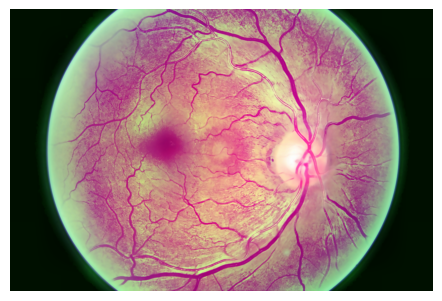

In [9]:
image_path = 'C:\\APU\\APU Y2 Sem 2\\ISE\\Processed image\\download1.png'  
denoise_image(image_path)

In [10]:
def compute_psnr(img1_path, img2_path):
    # Read the two images
    img1 = cv2.imread(img1_path, cv2.IMREAD_COLOR)
    img2 = cv2.imread(img2_path, cv2.IMREAD_COLOR)
    img1 = cv2.resize(img1, (img2.shape[1], img2.shape[0]))
    
    # Ensure both images have the same dimensions
    if img1.shape != img2.shape:
        raise ValueError("Both images must have the same dimensions.")
    
    # Compute the Mean Squared Error (MSE) between the two images
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        # Both images are identical, so PSNR is theoretically infinite
        return float('inf')

    # Calculate the PSNR using the formula: PSNR = 20 * log10(MAX_I) - 10 * log10(MSE)
    # where MAX_I is the maximum pixel value in the image (255 for 8-bit images)
    psnr = 20 * np.log10(255) - 10 * np.log10(mse)

    return psnr

In [11]:
original_image_path = 'C:\\APU\\APU Y2 Sem 2\\ISE\\Dataset filtered\\108_left.jpeg'
enhanced_image_path = 'C:\\APU\\APU Y2 Sem 2\\ISE\\Processed image\\output6.png'
psnr_value = compute_psnr(original_image_path, enhanced_image_path)

print(f"PSNR between original and enhanced image: {psnr_value:.2f} dB")

PSNR between original and enhanced image: 30.53 dB
